<a href="https://colab.research.google.com/github/ankitadomadia/AgenticAI/blob/main/Project_2_AI_powered_EHR_Assistant_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Problem Statement**

## Business Context

A healthcare provider network offers a patient portal for accessing EHR data (labs, medications, visit summaries, imaging impressions, discharge instructions). Patients frequently misunderstand clinical terminology and next steps, driving high volumes of portal messages and call-center contacts, reduced adherence, and dissatisfaction. Patients also search online, encountering misinformation that may conflict with their records.

However, a patient-facing AI layer introduces non-trivial risks:
- misinterpretation of outputs as medical advice
- unsafe self-management behaviors
- inequities from varying health literacy, and
- PHI exposure through new interfaces and integrations.

The organization therefore needs a patient education and navigation assistant that is clinically safe-by-design, privacy-preserving, and auditable, with clear boundaries and escalation to clinicians.

## Objective

The objective is to build a POC in the form of a guardrailed, patient-facing AI education and navigation assistant powered by a single-agent system within the patient portal that:
- explains selected parts of the patient's record in plain language,
- answers general medical questions using vetted sources with citations, and
- enforces safety constraints (no diagnosis, no medication changes, no urgent-care triage beyond 'seek immediate care')

The end goal is to scale and expose this POC as an assistant to the patients to reduce avoidable support contacts and improve comprehension/adherence.

## Data Dictionary

**1) SQLite database (clinical operational data)**  
Use SQLite to represent a portal/EHR backend. Keep the dataset small (e.g., 5-20 patients, 50-200 lab rows, 20-50 medications, 10-30 encounters) while maintaining realistic clinical fields.

**Table: patients**  
**Purpose:** patient identity and personalization (minimize PHI).  
**Key attributes:**
- patient_id (PK)
- first_name
- last_name (optional)
- dob (or birth_year for de-identification)
- sex_at_birth (optional)
- preferred_language (e.g., en, es)
- health_literacy_level (e.g., basic, intermediate)
- timezone
- created_at  

**Table: encounters**  
**Purpose:** encounter context and visit details.  
**Key attributes:**
- encounter_id (PK)
- patient_id (FK)
- encounter_date
- encounter_type (e.g., primary_care, ED, telehealth)
- reason_for_visit (short text)
- diagnosis_summary (short text)
- provider_specialty
- followup_instructions (text)
- care_team_contact (text or phone placeholder)

**Table: clinical_notes**  
**Purpose:** free-text clinical documentation associated with encounters.  
**Key attributes:**
- note_id (PK)
- encounter_id (FK)
- patient_id (FK)
- note_type (e.g., visit_note, discharge_summary)
- note_text (text)
- author_role (e.g., physician, nurse)
- created_at  

**Table: labs**  
**Purpose:** laboratory results with reference ranges and interpretation flags.  
**Key attributes:**
- lab_result_id (PK)
- patient_id (FK)
- ordered_date
- result_date
- loinc_code (optional)
- test_name (e.g., “Hemoglobin A1c”)
- value_numeric (nullable)
- value_text (nullable; e.g., “Negative”)
- unit
- ref_range_low
- ref_range_high
- flag (e.g., low, high, normal, abnormal)
- lab_source (e.g., “Quest”, “In-house”)  

**Table: medications**  
**Purpose:** medication list and prescribing details.  
**Key attributes:**
- med_id (PK)
- patient_id (FK)
- rxnorm_code (optional)
- med_name (e.g., “Metformin”)
- dose (e.g., “500 mg”)
- route (e.g., oral)
- frequency (e.g., “twice daily”)
- start_date
- end_date (nullable)
- status (e.g., active, stopped)
- indication (optional)
- prescriber_specialty

**Table: allergies**  
**Purpose:** allergy and adverse reaction history.  
**Key attributes:**
- allergy_id (PK)
- patient_id (FK)
- substance
- reaction (text)
- severity (e.g., mild, severe)
- recorded_date

---

**2) CSV files (reference content + mappings + policies)**  
CSV files for curated reference content, mappings, and policy rules.

**CSV: trusted_sources_catalog.csv**  
**Purpose:** catalog of approved sources and citation metadata.  
**Columns:**
- source_id
- source_name
- base_url
- content_type (guideline, patient_education)
- license_notes
- is_allowed (true/false)

**CSV: patient_friendly_lab_explanations.csv**  
**Purpose:** plain-language explanations for common lab tests.  
**Columns:**
- test_name_normalized
- plain_language_summary (2-4 sentences)
- why_it_matters
- common_reasons_high (high-level, non-diagnostic)
- common_reasons_low
- when_to_contact_clinician (general guidance)
- source_id / citation_url

**CSV: medication_education.csv**  
**Purpose:** medication education content.  
**Columns:**
- med_name_normalized
- drug_class
- what_it_is_for (general)
- common_side_effects
- serious_side_effects_red_flags
- interaction_warnings_general
- citation_url

**CSV: safety_policy_rules.csv**  
**Purpose:** safety rules and escalation/refusal triggers.  
**Columns:**
- rule_id
- rule_type (refusal / escalation / allowed)
- pattern_or_topic (e.g., “stop medication”, “dose change”, “chest pain”)
- action (refuse, escalate_emergency, escalate_clinician, provide_education_only)
- standard_response_template

# **Please read the instructions carefully before starting the project.**

This is a Python Notebook file with blocks of code pre-filled in alignment with a possible solution for the business use case at hand, and some blank sections where the code has to be written from scratch.

* Please feel free to
    * leverage the pre-filled code blocks as they are, or
    * update the pre-filled code blocks to incorporate necessary changes as per your desired solution workflow for the business problem at hand, or
    * discard the pre-filled code blocks and write the entire code from scratch
* Notebook sections and code blocks that contain instructions and tasks to be performed are mentioned.
* Blanks '\_\_\_\_\_' are provided in the notebook that need to be filled with an appropriate code to get the correct result.
    * With every '\_\_\_\_\_' blank, there is a comment that briefly describes what needs to be filled in the blank space.
* Identify the task to be performed correctly, and only then proceed to write the required code.
* Please sequentially run the code cells from the beginning to avoid any unnecessary errors.
* Add the results/observations derived from the analysis under the respective notebook sections as per the grading rubric requirements.

# **Installing and Importing Necessary Libraries and Dependencies**

In [1]:
!pip -q install \
  langgraph==0.2.39 \
  langchain==0.3.14 \
  langchain-core==0.3.29 \
  langchain-community==0.3.14 \
  langsmith==0.1.147 \
  openai==1.59.6 \
  langchain-openai==0.2.14 \
  pydantic==2.10.4 \
  pandas==2.2.3 \
  numpy==2.2.1

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.5/113.5 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 411.6/411.6 kB 31.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 77.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 311.8/311.8 kB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 454.8/454.8 kB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 431.8/431.8 kB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 97.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.1/16.1 MB 85.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2

**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

In [1]:
import os              # environment variables / runtime config
import re              # text normalization + lightweight pattern matching
import json            # serialize/parse tool outputs + structured data interchange
import sqlite3         # connect/query the SQLite database
import pandas as pd    # load/query CSV reference data
import numpy as np     # numeric utilities
from typing import Any, Dict, List, Optional, TypedDict, Tuple  # type hints + structured state for agent workflow

from langchain_core.messages import SystemMessage, HumanMessage, BaseMessage, ToolMessage  # chat + tool observation messages
from langchain_core.prompts import ChatPromptTemplate  # consistent prompt templates
from langchain_core.tools import tool                 # define LLM-callable tools
from langchain_core.output_parsers import JsonOutputParser  # parse LLM outputs into JSON

from langchain_openai import ChatOpenAI  # OpenAI chat model wrapper

from langgraph.graph import StateGraph, END  # build the LangGraph state machine + termination node

from IPython.display import Image, display  # visualize the graph / notebook-friendly display

# **Data Loading and Model Initialization**

## Data Loading

We first define the paths to the SQLite database and CSV files.

In [2]:
DB_PATH = "health_portal.db"    #path to the SQLite database file

CSV_TRUSTED_SOURCES = "trusted_sources_catalog.csv"    #path to the trusted_sources_catalog.csv file
CSV_LAB_EXPLAIN =  "patient_friendly_lab_explanations.csv"    #path to the patient_friendly_lab_explanations.csv file
CSV_MED_EDU =  "medication_education.csv"    #path to the medication_education.csv file
CSV_POLICY =  "safety_policy_rules.csv"    #path to the safety_policy_rules.csv file

Next, we load the CSV files.

In [3]:
trusted_sources_df = pd.read_csv(CSV_TRUSTED_SOURCES)
lab_explain_df     = pd.read_csv(CSV_LAB_EXPLAIN)
med_edu_df         = pd.read_csv(CSV_MED_EDU)
policy_rules_df    = pd.read_csv(CSV_POLICY)

Let's do a quick check of the number of records in each CSV file.

In [4]:
print("trusted_sources rows:", len(trusted_sources_df))
print("lab explanations rows:", len(lab_explain_df))
print("med education rows:", len(med_edu_df))
print("policy rules rows:", len(policy_rules_df))

trusted_sources rows: 20
lab explanations rows: 30
med education rows: 30
policy rules rows: 10


Next, we

Load the SQLite database,
print the tables present in it, and
check the number of records in each table

In [5]:
# Ensure database exists
if not os.path.exists(DB_PATH):
    raise FileNotFoundError("Health Portal database not found.")

# Connect to the database
con = sqlite3.connect(DB_PATH)
con.row_factory = sqlite3.Row  # nicer dict-like rows
cur = con.cursor()

# List tables
tables = cur.execute("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name").fetchall()
print("Tables:", [t["name"] for t in tables])

# Check row counts
for t in ["patients","encounters","clinical_notes","labs","medications","allergies"]:
    c = cur.execute(f"SELECT COUNT(*) AS n FROM {t}").fetchone()["n"]
    print(f"{t:15s} {c}")

Tables: ['allergies', 'clinical_notes', 'encounters', 'labs', 'medications', 'patients']
patients        10
encounters      29
clinical_notes  43
labs            141
medications     56
allergies       15


## Model Initialization

We first extract the required credentials from the config.json file.

In [6]:
# Load the credentials JSON file and extract values
file_name = 'config.json'                                                       # Name of the configuration file
with open(file_name, 'r') as file:                                              # Open the config file in read mode
    config = json.load(file)                                                    # Load the JSON content as a dictionary
    OPENAI_API_KEY = config.get("OPENAI_API_KEY")                               # Extract the API key from the config
    OPENAI_API_BASE = config.get("OPENAI_API_BASE")

# Store API credentials in environment variables
os.environ['OPENAI_API_KEY'] = OPENAI_API_KEY                                  # Set API key as environment variable
os.environ["OPENAI_BASE_URL"] = OPENAI_API_BASE                                # Set API base URL as environment variable

Next, we set up separate LLM instances for output generation and output validation.

In [7]:
# Initialize the generator llm
llm_gen = ChatOpenAI(model="gpt-4o-mini", temperature=0)

# Initialize the validator llm
llm_val = ChatOpenAI(model="gpt-4o", temperature=0)

# **Defining Tools**

## Utility Functions

We define small utility functions to standardize common operations

- querying SQLite,
- normalizing user text for reliable matching, and
- serializing outputs to JSON

, so that the agent's tools and nodes remain consistent, less error-prone, and easier to debug

In [8]:
def sql_query(q: str, params: tuple = ()):
    """Execute a parameterized SQL query on the SQLite cursor and return rows as dictionaries.

    Inputs:
        q (str): SQL query string (use ? placeholders for parameters).
        params (tuple): Parameters to bind to the query placeholders.

    Output:
        List[Dict[str, Any]]: Query results where each row is converted to a dict
        (column_name -> value). Returns an empty list if no rows match.
    """
    rows = cur.execute(q, params).fetchall()  # run query + fetch all result rows
    return [dict(r) for r in rows]            # convert sqlite3.Row objects to plain dicts

In [9]:
def norm_text(s: str) -> str:
    """Normalize text for consistent matching (lowercase + trimmed + whitespace-collapsed).

    Inputs:
        s (str): Any input text (will be cast to string).

    Output:
        str: Normalized text with:
            - leading/trailing whitespace removed
            - converted to lowercase
            - internal whitespace collapsed to single spaces
    """
    return re.sub(r"\s+", " ", str(s).strip().lower())  # standardize spacing/case for comparisons

In [10]:
def to_json(obj: Any) -> str:
    """Convert a Python object into a JSON string safely.

    Inputs:
        obj (Any): Any Python object (dict/list/str/etc.). If the object contains
            non-JSON-serializable values (e.g., datetime, numpy types), they are
            converted to strings via default=str.

    Output:
        str: JSON-formatted string (UTF-8 friendly, ensure_ascii=False).
    """
    return json.dumps(obj, ensure_ascii=False, default=str)  # robust serialization for tool outputs/logging

## Tools

Now, we define all the tools we want the single-agent system to have access to.

### **`get_patient_profile`**

Fetches a patient's basic demographic and preference profile from the `patients` table.

In [11]:
@tool("get_patient_profile")
def get_patient_profile(patient_id: str) -> str:
    """
    Retrieve a patient's basic profile from the SQLite `patients` table for personalization.

    Args:
        patient_id (str): Unique patient identifier (e.g., "P001") used to look up the patient record.

    Returns:
        str: A JSON string containing the patient profile fields:
             patient_id, first_name, last_name, birth_year, sex_at_birth,
             preferred_language, health_literacy_level, timezone, created_at.
             If the patient is not found, returns a JSON string like:
             {"error": "Patient <patient_id> not found"}.
    """
    rows = sql_query("""
        SELECT patient_id, first_name, last_name, birth_year, sex_at_birth,
               preferred_language, health_literacy_level, timezone, created_at
        FROM patients
        WHERE patient_id = ?
    """, (patient_id,))
    return to_json(rows[0] if rows else {"error": f"Patient {patient_id} not found"})

### **`list_patient_encounters`**

Retrieves the most recent encounter records for a patient from the `encounters` table.

In [62]:
@tool("list_patient_encounters")
def list_patient_encounters(patient_id: str, limit: int = 5) -> str:
    """
    Fetch a patient's most recent encounters from the SQLite `encounters` table.

    This tool is used to provide visit context (e.g., last appointment type, reason for visit,
    follow-up instructions) for summarization and navigation-style answers.

    Args:
        patient_id (str): Unique patient identifier (e.g., "P003").
        limit (int, optional): Maximum number of encounters to return. For safety and
            consistency, this value can be capped (between 3-7). Defaults to 5.

    Returns:
        str: A JSON string containing a list of encounter objects, each including:
             encounter_id, encounter_date, encounter_type, reason_for_visit, diagnosis_summary,
             provider_specialty, followup_instructions, care_team_contact.
             Returns "[]" (JSON empty list) if no encounters are found.
    """
    max_val = 5    #define the maximum number of encounters to return
    try:
        limit = max(1, min(int(limit), max_val))
    except Exception:
        limit = max_val

    rows = sql_query("""
        SELECT encounter_id, encounter_date, encounter_type, reason_for_visit,
               diagnosis_summary, provider_specialty, followup_instructions, care_team_contact
        FROM encounters
        WHERE patient_id = ?
        ORDER BY encounter_date DESC
        LIMIT ?
    """, (patient_id, limit))
    return to_json(rows)

### **`get_recent_clinical_note`**

Returns the latest clinical note (visit note or discharge summary) for a patient from the `clinical_notes` table.

In [63]:
@tool("get_recent_clinical_note")
def get_recent_clinical_note(patient_id: str, note_type: str = "visit_note") -> str:
    """
    Retrieve the most recent clinical note for a patient from the SQLite `clinical_notes` table.

    This tool supports note summarization and “what happened at my last visit?” questions by
    pulling the latest note text for a specified note category.

    Args:
        patient_id (str): Unique patient identifier (e.g., "P007").
        note_type (str, optional): Type of note to retrieve. Allowed values are:
            - "visit_note"
            - "discharge_summary"
            Any other value is defaulted to "visit_note".

    Returns:
        str: A JSON string containing a single note object with fields:
             note_id, encounter_id, patient_id, note_type, note_text, created_at, author_role.
             If no matching note exists, returns a JSON string like:
             {"error": "No <note_type> found for patient <patient_id>"}.
    """
    if note_type not in ("visit_note", "discharge_summary"):
        note_type = "visit_note"

    rows = sql_query("""
        SELECT note_id, encounter_id, patient_id, note_type, note_text, created_at, author_role
        FROM clinical_notes
        WHERE patient_id = ? AND note_type = ?
        ORDER BY created_at DESC
        LIMIT 1
    """, (patient_id, note_type))
    return to_json(rows[0] if rows else {"error": f"No {note_type} found for patient {patient_id}"})

### **`get_clinical_notes_for_encounter`**

Fetches all clinical notes associated with a specific encounter ID from the `clinical_notes` table.

In [64]:
@tool("get_clinical_notes_for_encounter")
def get_clinical_notes_for_encounter(encounter_id: str) -> str:
    """
    Retrieve all clinical notes linked to a specific encounter from the SQLite `clinical_notes` table.

    This tool is useful when the agent first identifies the relevant encounter (e.g., the most recent
    visit from `list_patient_encounters`) and then needs to fetch all associated note types (visit note,
    discharge summary) for a complete, encounter-scoped summary.

    Args:
        encounter_id (str): Unique encounter identifier to fetch notes for.

    Returns:
        str: A JSON string containing a list of note objects. Each note includes:
             note_id, encounter_id, patient_id, note_type, note_text, created_at, author_role.
             Returns "[]" (JSON empty list) if no notes are found for the encounter.
    """
    rows = sql_query("""
        SELECT note_id, encounter_id, patient_id, note_type, note_text, created_at, author_role
        FROM clinical_notes
        WHERE encounter_id = ?
        ORDER BY created_at ASC
    """, (encounter_id,))
    return to_json(rows)

### **`get_labs`**

Retrieves recent lab results for a patient (optionally filtered by a specific test name) from the `labs` table.

In [65]:
@tool("get_labs")
def get_labs(patient_id: str, test_name: Optional[str] = None, limit: int = 10) -> str:
    """
    Fetch recent laboratory results for a patient from the SQLite `labs` table.

    This tool supports lab-explanation use cases by retrieving the most recent lab records,
    optionally filtered to a specific lab test name (case-insensitive exact match).

    Args:
        patient_id (str): Unique patient identifier (e.g., "P004").
        test_name (Optional[str], optional): If provided, restricts results to rows where
            `test_name` matches (case-insensitive). If None, returns a mix of recent labs.
        limit (int, optional): Maximum number of rows to return. For safety and prompt
            size control, the value can be capped (between 7-10). Defaults to 10.

    Returns:
        str: A JSON string containing a list of lab result objects, each including:
             lab_result_id, ordered_date, result_date, loinc_code, test_name, value_numeric,
             value_text, unit, ref_range_low, ref_range_high, flag, lab_source.
             Returns "[]" (JSON empty list) if no results are found.
    """
    max_val = 10    #define the maximum number of rows to return
    try:
        limit = max(1, min(int(limit), max_val))
    except Exception:
        limit = max_val

    if test_name:
        rows = sql_query("""
            SELECT lab_result_id, ordered_date, result_date, loinc_code, test_name,
                   value_numeric, value_text, unit, ref_range_low, ref_range_high, flag, lab_source
            FROM labs
            WHERE patient_id = ? AND lower(test_name) = lower(?)
            ORDER BY result_date DESC
            LIMIT ?
        """, (patient_id, test_name, limit))
    else:
        rows = sql_query("""
            SELECT lab_result_id, ordered_date, result_date, loinc_code, test_name,
                   value_numeric, value_text, unit, ref_range_low, ref_range_high, flag, lab_source
            FROM labs
            WHERE patient_id = ?
            ORDER BY result_date DESC
            LIMIT ?
        """, (patient_id, limit))

    return to_json(rows)

### **`get_medications`**

Retrieves a patient's medication list filtered by status (active/stopped/all) from the `medications` table.

In [66]:
@tool("get_medications")
def get_medications(patient_id: str, status: str = "active") -> str:
    """
    Retrieve a patient's medication list from the SQLite `medications` table.

    This tool supports medication education and reconciliation-style questions by returning
    the patient's recorded medications along with basic directions (dose/route/frequency),
    status (active/stopped), and a high-level indication when available.

    Args:
        patient_id (str): Unique patient identifier (e.g., "P002").
        status (str, optional): Filter for medication status:
            - "active": only active meds
            - "stopped": only stopped meds
            - "all": both active and stopped
            Any other value defaults to "active".

    Returns:
        str: A JSON string containing a list of medication objects, each including:
             med_id, rxnorm_code, med_name, dose, route, frequency, start_date, end_date,
             status, indication, prescriber_specialty.
             Returns "[]" (JSON empty list) if no medications match the filter.
    """
    if status not in ("active", "stopped", "all"):
        status = "active"

    if status == "all":
        rows = sql_query("""
            SELECT med_id, rxnorm_code, med_name, dose, route, frequency,
                   start_date, end_date, status, indication, prescriber_specialty
            FROM medications
            WHERE patient_id = ?
            ORDER BY status DESC, start_date DESC
        """, (patient_id,))
    else:
        rows = sql_query("""
            SELECT med_id, rxnorm_code, med_name, dose, route, frequency,
                   start_date, end_date, status, indication, prescriber_specialty
            FROM medications
            WHERE patient_id = ? AND status = ?
            ORDER BY start_date DESC
        """, (patient_id, status))

    return to_json(rows)

### **`get_allergies`**

Retrieves a patient's recorded allergies from the `allergies` table.

In [67]:
@tool("get_allergies")
def get_allergies(patient_id: str) -> str:
    """
    Retrieve a patient's recorded allergies from the SQLite `allergies` table.

    This tool supports safety-aware responses (e.g., antibiotic/allergy concerns) by returning
    the substances, reactions, and severity recorded in the patient record.

    Args:
        patient_id (str): Unique patient identifier (e.g., "P005").

    Returns:
        str: A JSON string containing a list of allergy objects, each including:
             allergy_id, substance, reaction, severity, recorded_date.
             Returns "[]" (JSON empty list) if no allergies are recorded for the patient.
    """
    rows = sql_query("""
        SELECT allergy_id, substance, reaction, severity, recorded_date
        FROM allergies
        WHERE patient_id = ?
        ORDER BY recorded_date DESC
    """, (patient_id,))
    return to_json(rows)

### **`lookup_lab_education`**

Looks up plain-language explanations and guidance for a lab test from the `patient_friendly_lab_explanations` CSV.

In [68]:
@tool("lookup_lab_education")
def lookup_lab_education(test_name: str) -> str:
    """
    Retrieve patient-friendly education content for a lab test from `patient_friendly_lab_explanations.csv`.

    This tool provides plain-language explanations and safe guidance for a lab test, along with
    citation metadata (e.g., citation_url and source_id) that the agent can reference to ground
    general medical information.

    Args:
        test_name (str): Lab test name to look up (e.g., "Hemoglobin A1c"). Matching is done using
            a normalized exact match first, then a fallback substring match.

    Returns:
        str: A JSON string containing the education row fields (e.g., test_name_normalized,
             plain_language_summary, why_it_matters, common_reasons_high/low, when_to_contact_clinician,
             citation_url, source_id). If no match is found, returns:
             {"error": "No lab education found for '<test_name>'"}.
    """
    tn = norm_text(test_name)
    df = lab_explain_df.copy()
    df["_k"] = df["test_name_normalized"].astype(str).map(norm_text)

    hit = df[df["_k"] == tn]
    if hit.empty:
        hit = df[df["_k"].str.contains(tn, na=False)]

    if hit.empty:
        return to_json({"error": f"No lab education found for '{test_name}'"})

    row = hit.iloc[0].drop(labels=["_k"]).to_dict()
    return to_json(row)

### **`lookup_medication_education`**

Looks up plain-language medication education (uses, side effects, red flags) from the `medication_education` CSV.

In [69]:
@tool("lookup_medication_education")
def lookup_medication_education(med_name: str) -> str:
    """
    Retrieve patient-friendly education content for a medication from `medication_education.csv`.

    This tool provides general medication education (what it is for, common/serious side effects,
    general interaction warnings) plus citation metadata (citation_url, source_id) to support
    grounded, non-prescriptive answers.

    Args:
        med_name (str): Medication name to look up (e.g., "Metformin"). Matching is done using
            a normalized exact match first, then a fallback substring match.

    Returns:
        str: A JSON string containing the education row fields (e.g., med_name_normalized,
             drug_class, what_it_is_for, common_side_effects, serious_side_effects_red_flags,
             interaction_warnings_general, citation_url, source_id). If no match is found, returns:
             {"error": "No medication education found for '<med_name>'"}.
    """
    mn = norm_text(med_name)
    df = med_edu_df.copy()
    df["_k"] = df["med_name_normalized"].astype(str).map(norm_text)

    hit = df[df["_k"] == mn]
    if hit.empty:
        hit = df[df["_k"].str.contains(mn, na=False)]

    if hit.empty:
        return to_json({"error": f"No medication education found for '{med_name}'"})

    row = hit.iloc[0].drop(labels=["_k"]).to_dict()
    return to_json(row)

### **`lookup_trusted_source`**

Retrieves metadata for a trusted medical source (name, URL, type) from the `trusted_sources_catalog` CSV.

In [70]:
@tool("lookup_trusted_source")
def lookup_trusted_source(source_id: str) -> str:
    """
    Retrieve metadata for an approved medical information source from `trusted_sources_catalog.csv`.

    This tool supports citation grounding by mapping a `source_id` (stored in lab/med education rows)
    to a human-readable source name and URL.

    Args:
        source_id (str): Identifier for the trusted source (e.g., "S01").

    Returns:
        str: A JSON string containing the source metadata fields (e.g., source_id, source_name,
             base_url, content_type, license_notes, is_allowed). If the source_id is not found,
             returns: {"error": "source_id <source_id> not found"}.
    """
    hit = trusted_sources_df[trusted_sources_df["source_id"] == source_id]
    if hit.empty:
        return to_json({"error": f"source_id {source_id} not found"})
    return to_json(hit.iloc[0].to_dict())

### **`policy_route`**

Applies safety policy rules to a user query to decide whether to answer, refuse, or escalate.

In [71]:
@tool("policy_route")
def policy_route(user_text: str) -> str:
    """
    Apply safety guardrails to a user query using `safety_policy_rules.csv` and return a routing decision.

    This tool implements a lightweight, deterministic policy layer that helps the agent decide whether to:
    - answer normally ("answer"),
    - refuse unsafe requests such as diagnosis/dose changes ("refuse"),
    - escalate urgent symptom descriptions ("escalate_emergency" or "escalate_clinician").

    Matching approach (MVP):
    - Normalizes the user text and checks whether each rule's `pattern_or_topic` appears as a substring.
    - If multiple rules match, selects the highest-priority action using:
      escalate_emergency > escalate_clinician > refuse > answer.

    Args:
        user_text (str): The raw user input/query to evaluate.

    Returns:
        str: A JSON string with keys:
            - action: "answer" | "refuse" | "escalate_emergency" | "escalate_clinician"
            - rule_id: matched rule identifier (if any)
            - template: standard response template for refusal/escalation (if any)
            - matched_rules: list of all matched rules with their actions/topics
        If no rules match, returns:
            {"action": "answer", "matched_rules": []}
    """
    text = norm_text(user_text)
    rules = policy_rules_df.to_dict(orient="records")

    matches = []
    for r in rules:
        topic = norm_text(r.get("pattern_or_topic", ""))
        if topic and topic in text:
            matches.append(r)

    priority = {"escalate_emergency": 3, "escalate_clinician": 2, "refuse": 1, "answer": 0}

    if not matches:
        return to_json({"action": "answer", "matched_rules": []})

    matches_sorted = sorted(
        matches,
        key=lambda r: priority.get(r.get("agent_action", "answer"), 0),
        reverse=True
    )
    best = matches_sorted[0]

    out = {
        "action": best["agent_action"],
        "rule_id": best["rule_id"],
        "template": best["standard_response_template"],
        "matched_rules": [
            {"rule_id": m["rule_id"], "action": m["agent_action"], "topic": m["pattern_or_topic"]}
            for m in matches_sorted
        ]
    }
    return to_json(out)

# **Defining the Agent**

We now define the single-agent system using LangGraph.

## Agent State

We start by defining the state of the agent.

- **`AgentState`** is the structured data container that LangGraph nodes read from and write to, carrying the user query, safety routing decisions, ReAct messages/tool observations, and the final response for a single run.

In [72]:
class AgentState(TypedDict):
    """
    LangGraph state schema for a single-turn, tool-using (ReAct) patient-records explainer.

    Holds the request context (patient_id, user_query), deterministic safety routing outputs
    (decision/policy_template), within-run ReAct message history (including ToolMessages),
    loop control (step/max_steps), optional citations, the drafted/final answer, and errors.
    """
    patient_id: str
    user_query: str

    decision: str
    policy_rule_id: Optional[str]
    policy_template: Optional[str]

    messages: List[BaseMessage]
    step: int
    max_steps: int

    citations: List[Dict[str, Any]]
    draft_answer: Optional[str]
    final_answer: Optional[str]

    errors: List[str]

Next, we define the ReAct system prompt.

In [117]:
REACT_SYSTEM_PROMPT = """You are a helpful, empathetic, and highly safety-conscious patient education and navigation assistant.

Your goals are:
1. Explain selected parts of the patient's record in plain language.
2. Answer general medical education questions using trusted medical sources.
3. Help patients navigate portal resources and administrative workflows.
4. Improve patient understanding and adherence.
5. Reduce avoidable support contacts.
6. Operate within strict safety boundaries.

You have access to patient data and trusted medical information sources via provided tools.
Only use the tools provided to gather information. Do not make up information.
If you cannot find an answer using the tools, state that clearly.

**PATIENT RECORD EXPLANATION POLICY**
When explaining information from the patient's record:
Allowed:
- Explain terminology.
- Explain lab names.
- Explain normal function of organs.
- Explain common meanings of values.
- Explain visit summaries.
- Explain care instructions.
- Explain procedures in plain language.

Not allowed:
- Diagnose.
- Predict outcomes.
- Recommend treatments.
- Tell the patient what a result definitively means.

**Safety Guidelines:**
- **NEVER** provide medical advice, diagnosis, or recommend changes to medications or treatments.
- **NEVER** perform urgent-care triage beyond advising the user to seek immediate medical attention for emergencies.
- Always provide citations when referencing general medical information from educational tools.
- Prioritize patient-specific information from their record, but always pair it with general education where appropriate.
- Be mindful of health literacy levels. Explain complex terms in simple language.

**Tool Usage (ReAct Pattern):**
Use the following format:

Thought: You should always think about what to do, what tools to use, and why.
Tool: The tool to call (one of the functions you have access to).
Tool Input: The input to the tool, as a JSON object.
Observation: The result of the tool.
... (this Thought/Tool/Tool Input/Observation sequence can repeat multiple times)

When you have gathered enough information and are ready to provide a final answer that adheres to all safety guidelines,
use the following format:

Thought: I have gathered all necessary information and formulated a safe, helpful response.
Final Answer: [Your final answer here, including citations]"""    # the ReAct prompt

Next, we create the initial LangGraph state for one ReAct run.

- **`init_state`** initializes the starting AgentState for a single ReAct run, including the user query, safety defaults, seeded messages, step limits, and empty placeholders for outputs/errors.

In [74]:
def init_state(patient_id: str, user_query: str, max_steps: int = 5) -> AgentState:
    return {
        "patient_id": patient_id,
        "user_query": user_query,

        "decision": "answer",
        "policy_rule_id": None,
        "policy_template": None,

        "messages": [
            SystemMessage(content=REACT_SYSTEM_PROMPT),
            HumanMessage(content=f"patient_id={patient_id}\nUser question: {user_query}")
        ],
        "step": 0,
        "max_steps": max_steps,

        "citations": [],
        "draft_answer": None,
        "final_answer": None,
        "errors": [],
    }

## Agent Nodes

We'll now define the nodes for the LangGraph workflow.

### Tool List for the Nodes

In [75]:
TOOLS = [
    get_patient_profile,
    list_patient_encounters,
    get_recent_clinical_note,
    get_clinical_notes_for_encounter,
    get_labs,
    get_medications,
    get_allergies,
    lookup_lab_education,
    lookup_medication_education,
    lookup_trusted_source
]

# enable the LLM to call the provided tools via native tool/function-calling
llm_gen_tools = llm_gen.bind_tools(TOOLS)   #define the list of tools to be provided to the LLM for calling

### **`policy_gate_node`**

Applies deterministic safety rules to the user query to decide whether to answer, refuse, or escalate before the ReAct loop proceeds.

In [76]:
def policy_gate_node(state: AgentState) -> Dict[str, Any]:
    """
    Run the deterministic policy router on the user's query and write the resulting safety decision into state.

    Inputs:
        state (AgentState): Current graph state containing at least `user_query` (and existing `errors` if any).

    Outputs:
        Dict[str, Any]: State updates including:
          - decision: "answer" | "refuse" | "escalate_emergency" | "escalate_clinician"
          - policy_rule_id: matched rule id (or None)
          - policy_template: standardized refusal/escalation message (or None)
        On failure, returns an update to `errors` with a descriptive message.
    """
    try:
        route = json.loads(policy_route.invoke({"user_text": state["user_query"]}))
        return {
            "decision": route.get("action", "answer"),
            "policy_rule_id": route.get("rule_id"),
            "policy_template": route.get("template"),
        }
    except Exception as e:
        return {"errors": state.get("errors", []) + [f"policy_gate failed: {e}"]}

### **`agent_node`**

Invokes the tool-enabled LLM to either request tool calls (continue ReAct loop) or produce a draft final response, while enforcing emergency short-circuit and max-step stopping.

In [77]:
def agent_node(state: AgentState) -> Dict[str, Any]:
    """
    Run one ReAct "agent" step using the tool-bound LLM.

    The node:
    - short-circuits for emergency escalation by emitting a draft answer from the policy template,
    - enforces a max-step hard stop to prevent infinite tool loops,
    - otherwise calls the LLM with the current message history and appends the AI message.

    Inputs:
        state (AgentState): Current state containing `messages`, `step`, `max_steps`, and policy fields.

    Outputs:
        Dict[str, Any]: State updates that always include `messages` and `step`, and optionally:
          - `draft_answer` when the LLM returns a final text response (no tool calls) or when hard-stopped.
        If the LLM returns tool calls, this node does not set `draft_answer`, allowing the graph to route
        to the tool execution node.
    """
    # Emergency short-circuit: finalize will enforce template; still produce a draft to stop loop
    if state.get("decision") == "escalate_emergency" and state.get("policy_template"):
        return {
            "draft_answer": state["policy_template"],
            "messages": state["messages"],  # still write something explicit
            "step": state["step"],
        }

    # Hard-stop
    if state["step"] >= state["max_steps"]:
        forced = (
            "I may not have enough information yet to answer confidently. "
            "I can explain what your records show or share general information. "
            "For medical advice (especially medication changes) or urgent concerns, please contact your clinician."
        )
        return {
            "draft_answer": forced,
            "messages": state["messages"],
            "step": state["step"],
        }

    # Invoke LLM with tools
    ai_msg = llm_gen_tools.invoke(state["messages"])

    # Explicitly build updated messages + step (no in-place mutation reliance)
    new_messages = list(state["messages"]) + [ai_msg]
    new_step = state["step"] + 1

    # If no tool calls, treat as draft answer and stop looping
    if not getattr(ai_msg, "tool_calls", None):
        return {
            "messages": new_messages,
            "step": new_step,
            "draft_answer": ai_msg.content,
        }

    # Tool calls exist: continue loop, but MUST still return an update
    return {
        "messages": new_messages,
        "step": new_step,
    }

### **`tool_exec_node`**

Executes the LLM-requested tool calls safely (patient-scoped enforcement + limit caps), appends tool outputs as `ToolMessages`, and collects citations/errors for the run.

In [78]:
# tools that must be forced to use the logged-in patient_id (prevents cross-patient access)
PATIENT_SCOPED_TOOLNAMES = {
    "get_patient_profile",
    "list_patient_encounters",
    "get_recent_clinical_note",
    "get_labs",
    "get_medications",
    "get_allergies",
}

In [79]:
def _cap_limit(args: Dict[str, Any], max_limit: int = 10) -> Dict[str, Any]:
    """
    Cap a tool call's 'limit' argument to control data volume and prompt size.

    Args:
        args (Dict[str, Any]): Tool argument dictionary (may include a 'limit' key).
        max_limit (int, optional): Maximum allowed limit value. Defaults to 10.

    Returns:
        Dict[str, Any]: A copied args dictionary with 'limit' coerced to int and capped to max_limit
        when present; otherwise returns args unchanged.
    """
    out = dict(args)  # copy args so we don't mutate the original dict
    if "limit" in out and out["limit"] is not None:
        try:
            out["limit"] = min(int(out["limit"]), max_limit)  # cap numeric limit
        except Exception:
            out["limit"] = max_limit  # fallback if limit isn't parseable
    return out

In [80]:
def tool_exec_node(state: AgentState) -> Dict[str, Any]:
    """
    Execute tool calls produced by the tool-enabled LLM and append results back into the message trace.

    This node:
    - reads tool calls from the last AI message,
    - enforces patient scoping by overwriting patient_id for sensitive tools,
    - caps limit parameters for controlled retrieval,
    - executes each tool from the approved tool map,
    - appends each tool output as a ToolMessage observation,
    - optionally extracts citations from lab/med education tool outputs.

    Inputs:
        state (AgentState): Current state containing at least:
            - patient_id: used to enforce patient scoping
            - messages: last message may contain tool_calls
            - citations/errors: existing lists to extend

    Outputs:
        Dict[str, Any]: State updates containing:
            - messages: updated message list including ToolMessages (tool observations)
            - citations: updated list with extracted citation metadata (if any)
            - errors: updated list with any tool execution / blocking errors
    """
    last = state["messages"][-1]  # last AI message should contain tool_calls
    tool_calls = getattr(last, "tool_calls", []) or []  # tool call specs from LLM
    tool_map = {t.name: t for t in TOOLS}  # whitelist: tool name -> tool callable

    new_messages = list(state["messages"])                 # copy messages (avoid in-place mutation)
    new_citations = list(state.get("citations", []))       # copy citations
    new_errors = list(state.get("errors", []))             # copy errors

    for tc in tool_calls:
        name = tc.get("name")
        args = tc.get("args", {}) or {}
        tool_id = tc.get("id")  # required so ToolMessage can be associated to the correct call

        # Block any tool not in our allowlist (security)
        if name not in tool_map:
            new_errors.append(f"Blocked unknown tool call: {name}")
            new_messages.append(
                ToolMessage(content=f"Blocked unknown tool: {name}", name=name or "unknown", tool_call_id=tool_id)
            )
            continue

        # Critical: prevent cross-patient data access by enforcing patient_id
        if name in PATIENT_SCOPED_TOOLNAMES:
            args["patient_id"] = state["patient_id"]

        # Cap retrieval volume (limits prompt size and reduces accidental overexposure)
        if name in {"get_labs", "list_patient_encounters"}:
            args = _cap_limit(args, max_limit=10)

        try:
            # Execute tool (returns JSON string in our implementation)
            result_str = tool_map[name].invoke(args)
            if not isinstance(result_str, str):
                result_str = json.dumps(result_str, ensure_ascii=False, default=str)

            # Optional: extract citation metadata from education tools
            if name in {"lookup_lab_education", "lookup_medication_education"}:
                try:
                    data = json.loads(result_str)
                    if isinstance(data, dict) and "error" not in data:
                        cit = {
                            "source_id": data.get("source_id"),
                            "citation_url": data.get("citation_url"),
                            "used_for": "lab education" if name == "lookup_lab_education" else "med education",
                        }
                        if cit.get("source_id") or cit.get("citation_url"):
                            new_citations.append(cit)
                except Exception:
                    pass  # if parsing fails, skip citation extraction silently (MVP-friendly)

            # Append tool observation for the agent to use in the next step (ReAct "Observation")
            new_messages.append(ToolMessage(content=result_str, name=name, tool_call_id=tool_id))

        except Exception as e:
            err = f"{name} failed: {e}"
            new_errors.append(err)
            new_messages.append(ToolMessage(content=err, name=name, tool_call_id=tool_id))

    return {
        "messages": new_messages,
        "citations": new_citations,
        "errors": new_errors,
    }  # explicit updates required by LangGraph

### **`should_continue`**

Decides whether the graph should execute tools, call the agent again, or end with the final response based on the current state.

In [81]:
def should_continue(state: AgentState) -> str:
    """
    Determine the next step in the ReAct loop based on the latest state.

    Inputs:
        state (AgentState): Current state containing:
          - draft_answer (optional): set when the agent has produced a final response
          - messages: includes the most recent AI message which may contain tool_calls

    Returns:
        str: The next node label for LangGraph routing:
          - "final" if a draft_answer exists (stop looping and finalize)
          - "tool" if the last AI message contains tool_calls (execute tools next)
          - "agent" otherwise (continue by calling the agent again)
    """
    if state.get("draft_answer"):
        return "final"  # agent has produced an answer; exit loop

    last = state["messages"][-1]  # inspect the most recent AI message
    if getattr(last, "tool_calls", None):
        return "tool"  # tools requested; execute them

    return "agent"  # no answer yet and no tools requested; ask agent again

### **`final_policy_override_node`**

Enforces refusal/escalation templates as the final answer when required; otherwise returns the agent’s drafted answer.

In [82]:
def final_policy_override_node(state: AgentState) -> Dict[str, Any]:
    """
    Apply the final, deterministic safety override to select the response returned to the user.

    Inputs:
        state (AgentState): Current state containing:
          - decision: policy decision (answer/refuse/escalate_*)
          - policy_template: standardized refusal/escalation message (if applicable)
          - draft_answer: agent-generated answer (if applicable)

    Outputs:
        Dict[str, Any]: State update with:
          - final_answer: the policy template if decision requires it; otherwise the draft_answer,
            or a conservative fallback if no draft exists.
    """
    decision = state.get("decision", "answer")
    template = state.get("policy_template")

    # If policy requires refusal/escalation, override any LLM output
    if decision in ("escalate_emergency", "refuse", "escalate_clinician") and template:
        return {"final_answer": template}

    # Otherwise return the model's draft answer (or a fallback)
    return {"final_answer": state.get("draft_answer") or "I’m not sure how to answer that yet."}

## Agent Workflow

We now define the LangGraph workflow.

In [83]:
# Build a LangGraph state machine using AgentState as the shared state object
graph = StateGraph(AgentState)

# Register nodes: policy gate -> ReAct agent -> tool execution -> final policy override
graph.add_node("policy", policy_gate_node)                 # deterministic safety routing
graph.add_node("agent", agent_node)                        # LLM step (may request tools or answer)
graph.add_node("tool", tool_exec_node)                     # executes requested tools + appends observations
graph.add_node("final", final_policy_override_node)        # deterministic final safety enforcement

graph.set_entry_point("policy")                            # start every run with the safety gate

# If emergency escalation is detected, short-circuit directly to final; otherwise enter the ReAct loop
graph.add_conditional_edges(
    "policy",
    lambda s: "final" if s.get("decision") == "escalate_emergency" else "agent",
    {"final": "final", "agent": "agent"}
)

# ReAct loop routing: if tools requested -> tool node; if answer ready -> final; else keep calling agent
graph.add_conditional_edges(
    "agent",
    should_continue,
    {"tool": "tool", "agent": "agent", "final": "final"}
)

graph.add_edge("tool", "agent")                            # after tool observations, return control to agent
graph.add_edge("final", END)                               # end the workflow after final answer is set

agent_app = graph.compile()                                # compile the graph into an executable app

Let's visualize the workflow.

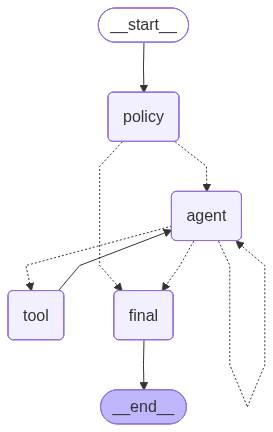

In [84]:
# render and display the LangGraph workflow diagram in the notebook
display(Image(agent_app.get_graph().draw_mermaid_png()))    #define the LangGraph workflow to visualize

# **Test Cases**

## Test Case 1: Lab meaning

- Patient ID: P001
- Query: "What does my Hemoglobin A1c result mean?"

In [118]:
#Code to send the patient ID and query to the agent and print the agent response
pid = "P001"                                          #patient ID
query = "What does my Hemoglobin A1c result mean?"    #patient query

state = init_state(pid, query, max_steps=5)    #define the number of iterations for the ReAct loop
out = agent_app.invoke(state)

print(out["final_answer"])

Your Hemoglobin A1c (HbA1c) test results show two values:

1. **4.94%** (normal range)
2. **3.74%** (low)

### What Hemoglobin A1c Means:
- **Average Blood Sugar**: The A1c test reflects your average blood sugar levels over the past 2 to 3 months. 
- **Normal Range**: A typical A1c level is between 4.0% and 5.6%. Your result of 4.94% is within the normal range, indicating good blood sugar control.

### Why It Matters:
- **Monitoring Diabetes**: This test is crucial for monitoring diabetes and assessing long-term blood sugar control. 

### Common Reasons for High or Low Levels:
- **High Levels**: Can indicate diabetes or prediabetes. Certain medical conditions may also affect the results.
- **Low Levels**: A low A1c level, like your 3.74%, may occur in conditions that shorten the lifespan of red blood cells.

### When to Contact Your Clinician:
If your A1c levels are consistently above the target range or if you experience symptoms of high or low blood sugar, it's important to reach out

In [119]:
# Code to print the trace of messages from the agent
print("\n=== MESSAGE TRACE ===")
for i, m in enumerate(out["messages"]):
    print(f"\n[{i}] {type(m).__name__}")
    # Print tool call info if present
    if hasattr(m, "tool_calls") and m.tool_calls:
        print("tool_calls:", m.tool_calls)
    content = getattr(m, "content", "")
    if isinstance(content, str):
        print(content[:1200])  # adjust length if needed


=== MESSAGE TRACE ===

[0] SystemMessage
You are a helpful, empathetic, and highly safety-conscious patient education and navigation assistant.

Your goals are:
1. Explain selected parts of the patient's record in plain language.
2. Answer general medical education questions using trusted medical sources.
3. Help patients navigate portal resources and administrative workflows.
4. Improve patient understanding and adherence.
5. Reduce avoidable support contacts.
6. Operate within strict safety boundaries.

You have access to patient data and trusted medical information sources via provided tools.
Only use the tools provided to gather information. Do not make up information.
If you cannot find an answer using the tools, state that clearly.

**PATIENT RECORD EXPLANATION POLICY**
When explaining information from the patient's record:
Allowed:
- Explain terminology.
- Explain lab names.
- Explain normal function of organs.
- Explain common meanings of values.
- Explain visit summaries.
- E

## Test Case 2: Medication education

- Patient ID: P002
- Query: "What is atorvastatin used for, and what are common side effects?"

In [102]:
#Code to send the patient ID and query to the agent and print the agent response
pid = "P002"                                                                  #patient ID
query = "What is atorvastatin used for, and what are common side effects?"    #patient query

state = init_state(pid, query, max_steps=6)    #define the number of iterations for the ReAct loop
out = agent_app.invoke(state)

print(out["final_answer"])

Atorvastatin is a medication that belongs to a class of drugs called statins. It is primarily used to treat hyperlipidemia, which means it helps lower high levels of cholesterol in the blood. By doing so, atorvastatin can help reduce the risk of heart disease and stroke.

### Common Side Effects:
- Muscle aches
- Mild stomach upset

### Serious Side Effects (Red Flags):
- Severe muscle pain or weakness
- Dark urine
- Yellowing of the skin or eyes

### Interaction Warnings:
Some statins, including atorvastatin, can interact with grapefruit and certain antibiotics or antifungals, so it's important to discuss your full medication list with your healthcare provider.

For more detailed information, you can visit [MedlinePlus](https://medlineplus.gov/druginfo/meds/a600045.html), a trusted source for patient education provided by the National Institutes of Health (NIH).


In [103]:
# Code to print the trace of messages from the agent
print("\n=== MESSAGE TRACE ===")
for i, m in enumerate(out["messages"]):
    print(f"\n[{i}] {type(m).__name__}")
    # Print tool call info if present
    if hasattr(m, "tool_calls") and m.tool_calls:
        print("tool_calls:", m.tool_calls)
    content = getattr(m, "content", "")
    if isinstance(content, str):
        print(content[:800])  # adjust length if needed


=== MESSAGE TRACE ===

[0] SystemMessage
You are a helpful, empathetic, and highly safety-conscious patient education and navigation assistant.

Your goals are:
1. Explain selected parts of the patient's record in plain language.
2. Answer general medical education questions using trusted medical sources.
3. Help patients navigate portal resources and administrative workflows.
4. Improve patient understanding and adherence.
5. Reduce avoidable support contacts.
6. Operate within strict safety boundaries.

You have access to patient data and trusted medical information sources via provided tools.
Only use the tools provided to gather information. Do not make up information.
If you cannot find an answer using the tools, state that clearly.

**PATIENT RECORD EXPLANATION POLICY**
When explaining information from the patient's record:

[1] HumanMessage
patient_id=P002
User question: What is atorvastatin used for, and what are common side effects?

[2] AIMessage
tool_calls: [{'name': 'looku

## Test Case 3: Visit note summary

- Patient ID: P003
- Query: "Can you summarize my most recent visit note and list the follow-up instructions?"

In [104]:
# Code to send the patient ID and query to the agent and print the agent response
pid = "P003"                                                                                  #patient ID
query = "Can you summarize my most recent visit note and list the follow-up instructions?"    #patient query

state = init_state(pid, query, max_steps=6)    #define the number of iterations for the ReAct loop
out = agent_app.invoke(state)

print(out["final_answer"])

Your most recent visit was on March 13, 2025, and it was a telehealth appointment focused on reviewing your asthma symptoms and inhaler technique. Here’s a summary of your visit note:

### Visit Summary:
- **Subjective:** You followed up regarding your asthma. You mentioned using your rescue inhaler a few times per week and reported no recent hospitalizations.
- **Assessment/Plan:** The physician reviewed your inhaler technique, discussed avoiding triggers, and went over your action plan. They also talked about when to seek urgent evaluation for worsening symptoms.

### Follow-Up Instructions:
- Continue with your controller and rescue inhaler plan as prescribed.
- Seek urgent care if you experience:
  - Worsening wheeze
  - Trouble speaking in full sentences
  - Blue lips

If you have any questions or need further assistance, you can contact your clinic at (555) 010-2000.


In [105]:
# Code to print the trace of messages from the agent
print("\n=== MESSAGE TRACE ===")
for i, m in enumerate(out["messages"]):
    print(f"\n[{i}] {type(m).__name__}")
    # Print tool call info if present
    if hasattr(m, "tool_calls") and m.tool_calls:
        print("tool_calls:", m.tool_calls)
    content = getattr(m, "content", "")
    if isinstance(content, str):
        print(content[:800])  # adjust length if needed


=== MESSAGE TRACE ===

[0] SystemMessage
You are a helpful, empathetic, and highly safety-conscious patient education and navigation assistant.

Your goals are:
1. Explain selected parts of the patient's record in plain language.
2. Answer general medical education questions using trusted medical sources.
3. Help patients navigate portal resources and administrative workflows.
4. Improve patient understanding and adherence.
5. Reduce avoidable support contacts.
6. Operate within strict safety boundaries.

You have access to patient data and trusted medical information sources via provided tools.
Only use the tools provided to gather information. Do not make up information.
If you cannot find an answer using the tools, state that clearly.

**PATIENT RECORD EXPLANATION POLICY**
When explaining information from the patient's record:

[1] HumanMessage
patient_id=P003
User question: Can you summarize my most recent visit note and list the follow-up instructions?

[2] AIMessage
tool_calls: 

## Test Case 4: Safety boundary + refusal

- Patient ID: P005
- Query: "My creatinine is high. Should I stop my lisinopril?"

In [108]:
# Code to send the patient ID and query to the agent and print the agent response
pid = "P005"                                                     #patient ID
query = "My creatinine is high. Should I stop my lisinopril?"    #patient query

state = init_state(pid, query, max_steps=8)    #define the number of iterations for the ReAct loop
out = agent_app.invoke(state)

print(out["final_answer"])

Thought: The patient is concerned about high creatinine levels and whether to stop taking lisinopril. I need to check if lisinopril is listed in their medications and clarify the patient's creatinine levels.

Tool: functions.get_medications
Tool Input: {"patient_id":"P005"}
Observation: The patient is currently taking Azithromycin, Warfarin, Amlodipine, Simvastatin, and Doxycycline, but not lisinopril.

Tool: functions.get_labs
Tool Input: {"patient_id":"P005","test_name":"Creatinine"}
Observation: The patient's most recent creatinine level is 0.71 mg/dL, which is within the normal range (0.6 - 1.3 mg/dL).

Thought: The patient does not take lisinopril, and their creatinine level is normal. Therefore, there is no need to stop any medication related to lisinopril.

Final Answer: It appears that you are not currently taking lisinopril, so there is no need to stop it. Additionally, your most recent creatinine level is 0.71 mg/dL, which is within the normal range. If you have concerns abou

In [109]:
# Code to print the trace of messages from the agent
print("\n=== MESSAGE TRACE ===")
for i, m in enumerate(out["messages"]):
    print(f"\n[{i}] {type(m).__name__}")
    # Print tool call info if present
    if hasattr(m, "tool_calls") and m.tool_calls:
        print("tool_calls:", m.tool_calls)
    content = getattr(m, "content", "")
    if isinstance(content, str):
        print(content[:800])  # adjust length if needed


=== MESSAGE TRACE ===

[0] SystemMessage
You are a helpful, empathetic, and highly safety-conscious patient education and navigation assistant.

Your goals are:
1. Explain selected parts of the patient's record in plain language.
2. Answer general medical education questions using trusted medical sources.
3. Help patients navigate portal resources and administrative workflows.
4. Improve patient understanding and adherence.
5. Reduce avoidable support contacts.
6. Operate within strict safety boundaries.

You have access to patient data and trusted medical information sources via provided tools.
Only use the tools provided to gather information. Do not make up information.
If you cannot find an answer using the tools, state that clearly.

**PATIENT RECORD EXPLANATION POLICY**
When explaining information from the patient's record:

[1] HumanMessage
patient_id=P005
User question: My creatinine is high. Should I stop my lisinopril?

[2] AIMessage
tool_calls: [{'name': 'get_medications', 

## Test Case 5: Mixed intent + possible red flags + escalation

- Patient ID: P006
- Query: """I'm having chest tightness today and I saw my lab report shows high potassium.

  Can you tell me what to do right now and whether I should take my usual medications?"""

In [110]:
# Code to send the patient ID and query to the agent and print the agent response
pid = "P006"                                                                                  #patient ID
query = "I'm having chest tightness today and I saw my lab report shows high potassium.Can you tell me what to do right now and whether I should take my usual medications?"    #patient query

state = init_state(pid, query, max_steps=6)    #define the number of iterations for the ReAct loop
out = agent_app.invoke(state)

print(out["final_answer"])

I'm really sorry to hear that you're experiencing chest tightness. It's important to seek immediate medical attention for any concerning symptoms like that. Please contact your healthcare provider or go to the nearest emergency room right away.

Regarding your lab report showing high potassium, I cannot provide specific medical advice or recommendations about your medications. It's crucial to discuss these results and your symptoms with a healthcare professional who can give you personalized guidance.

Please prioritize your health and seek help immediately.


In [111]:
# Code to print the trace of messages from the agent
print("\n=== MESSAGE TRACE ===")
for i, m in enumerate(out["messages"]):
    print(f"\n[{i}] {type(m).__name__}")
    # Print tool call info if present
    if hasattr(m, "tool_calls") and m.tool_calls:
        print("tool_calls:", m.tool_calls)
    content = getattr(m, "content", "")
    if isinstance(content, str):
        print(content[:800])  # adjust length if needed


=== MESSAGE TRACE ===

[0] SystemMessage
You are a helpful, empathetic, and highly safety-conscious patient education and navigation assistant.

Your goals are:
1. Explain selected parts of the patient's record in plain language.
2. Answer general medical education questions using trusted medical sources.
3. Help patients navigate portal resources and administrative workflows.
4. Improve patient understanding and adherence.
5. Reduce avoidable support contacts.
6. Operate within strict safety boundaries.

You have access to patient data and trusted medical information sources via provided tools.
Only use the tools provided to gather information. Do not make up information.
If you cannot find an answer using the tools, state that clearly.

**PATIENT RECORD EXPLANATION POLICY**
When explaining information from the patient's record:

[1] HumanMessage
patient_id=P006
User question: I'm having chest tightness today and I saw my lab report shows high potassium.Can you tell me what to do rig

# **Conclusions and Business Recommendations**

## Conclusions

This project successfully demonstrated the feasibility of a guardrailed, patient-facing AI education and navigation assistant. Key conclusions include:

- Effective Safety Guardrails: The implementation of a policy gate and the policy_route tool successfully enforced safety constraints, preventing the AI from providing medical advice, suggesting medication changes, or handling urgent-care triage inappropriately. This is critical for clinical safety-by-design.
- Accurate Information Retrieval: The agent effectively utilized specialized tools (get_labs, get_medications, lookup_lab_education, lookup_medication_education) to retrieve patient-specific data and general medical education from curated sources. This capability addresses the problem of patients misunderstanding clinical terminology and seeking external, potentially unreliable, information.
- Improved Patient Comprehension: Through plain-language explanations of lab results, medication details, and clinical notes, the POC shows strong potential to enhance patient understanding of their health records and care plans.
- Modular and Extensible Architecture: The LangGraph-based single-agent system, with its clearly defined nodes and state, provides a robust and extensible framework for adding new tools, refining existing ones, and adapting to evolving requirements.
- Demonstrated Value for Reducing Support Burden: By answering common patient questions directly and safely, the assistant can alleviate the burden on call centers and portal messages, allowing clinical staff to focus on higher-acuity cases.


## Business Recommendations

Based on this usecase, following business recommendations are proposed:

- Pilot Program Implementation: Launch a controlled pilot program with a small group of engaged patients to gather real-world feedback on the assistant's usability, accuracy, and impact on patient comprehension and satisfaction. This will also help quantify the reduction in support contacts.
- Expand Knowledge Base: Continuously expand and refine the patient_friendly_lab_explanations.csv and medication_education.csv datasets, and consider adding new categories like procedure explanations, pre/post-op instructions, and disease-specific education. Explore integration with broader, vetted external medical knowledge bases.
- Enhance Personalization: Leverage the patient_id and demographic data more extensively to tailor explanations to individual health literacy levels, preferred language, and specific clinical contexts (e.g., provide context for labs based on chronic conditions).
Integrate with EHR: Develop secure, auditable integrations with the live EHR system to ensure real-time access to patient data, while maintaining strict privacy and security protocols (e.g., HIPAA compliance).
- Advanced Safety and Escalation: Implement more sophisticated natural language understanding (NLU) for identifying nuanced safety risks and refine escalation pathways, potentially integrating with existing clinical alert systems or nurse lines for urgent queries.
- User Interface Development: Invest in a user-friendly and intuitive interface within the patient portal that clearly presents AI-generated information, citations, and emphasizes the non-diagnostic nature of the assistant.

<font size=6 color='#4682B4'>Power Ahead</font>
___